graphs\real\social\ego-facebook.pkl
Degree:rubustness=0.261813
Betweenness:rubustness=0.022769
CI:rubustness=0.260947
CoreHD:rubustness=0.261813
PageRank:rubustness=0.214580
FINDER:rubustness=0.250873
GDM:rubustness=0.153250
DomiRank:rubustness=0.284937
NIRM:rubustness=0.267873
GND:rubustness=0.359153
Ours-GCN-SAC:rubustness=0.231340
Ours-GraphSAGE-SAC:rubustness=0.183970
Ours-GIN-SAC:rubustness=0.143477
Ours-ResiflowGNN-SAC:rubustness=0.128792


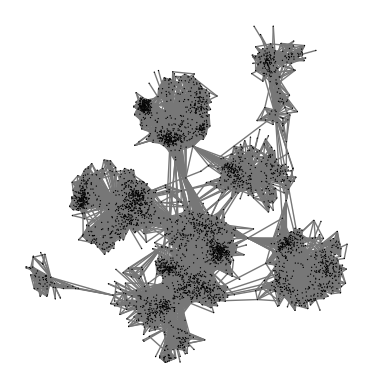

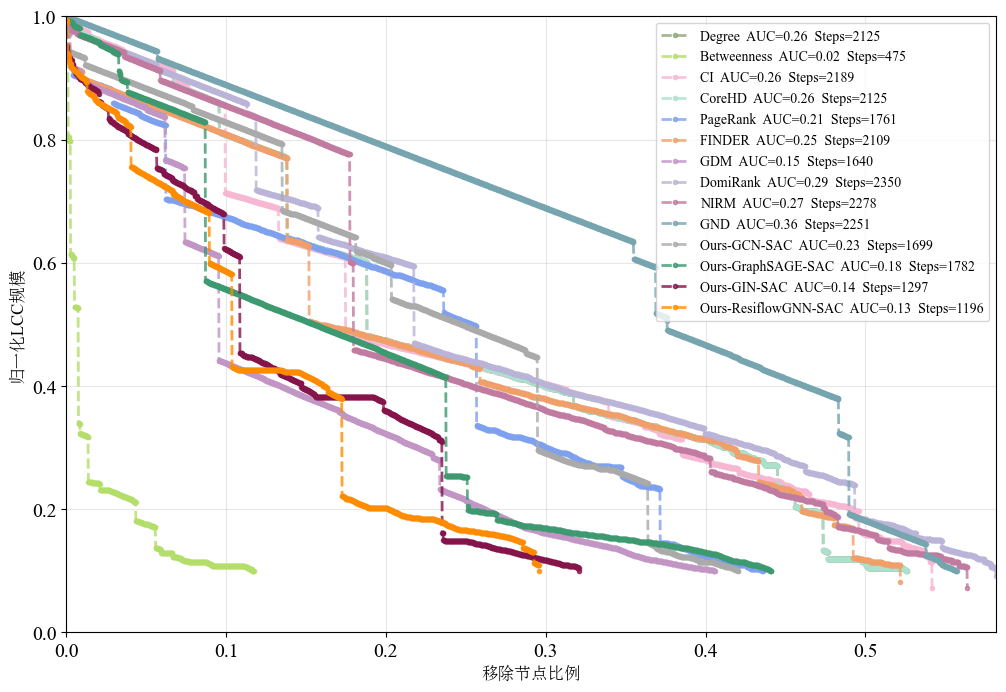

In [7]:
import igraph as ig
import os
import importlib
import baseline
from pathlib import Path
import visualize_dismantling
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils import graph_models
importlib.reload(graph_models)

from utils.plot import plot_graph
from utils.common import load_g
from utils.graph_models import *
from baseline import evaluate_sol


# g = SBM(80,p_in=0.15,p_out=0.0075,num_blocks=2)
# g = SBM(96,p_in=0.12,p_out=0.01,num_blocks=3)
# g = SBM(200, p_in=0.2,p_out=0.01, num_blocks=2)
# g = DCSBM(120,p_in=0.3,p_out=0.01,num_blocks=5)
# g = ring_community(120,p_in=0.2,num_communities=4)
# g = star_community(120,p_in=0.15,num_communities=5)
# g = barbell(120,p_in=0.1,path_len=3,type="ER")


# g_name = 'graphs/real/bio/foodweb-baywet.pkl'
# g_name = 'graphs/real/bio/foodweb-baydry.pkl'
# g_name = 'graphs/real/bio/maayan-foodweb.pkl'
# g_name = 'graphs/real/bio/dimacs10-celegansneural.pkl'
# g_name = 'graphs/real/bio/arenas-meta.pkl'
# g_name = 'graphs/real/bio/maayan-Stelzl.pkl'
# g_name = 'graphs/real/bio/moreno_propro.pkl'
# g_name = 'graphs/real/bio/maayan-figeys.pkl'
# g_name = 'graphs/real/bio/maayan-vidal.pkl'
# g_name = 'graphs/real/bio/ppi.pkl'
# g_name = 'graphs/real/social/librec-filmtrust-trust.pkl'
# g_name = 'graphs/real/social/opsahl-ucsocial.pkl'
# g_name = 'graphs/real/social/ego-facebook.pkl'
# g_name = 'graphs/real/social/librec-ciaodvd-trust.pkl'
# g_name = 'graphs/real/social/soc-Epinions1.pkl'

# g_name = 'graphs/real/information/dimacs10-polblogs.pkl'
# g_name = 'graphs/real/information/citeseer.pkl'
# g_name = 'graphs/real/information/dblp-cite.pkl'
# g_name = 'subelj_jdk_jdk'


root = Path("graphs/real")  # 或 Path(__file__).resolve().parents[1] / "graphs/real"
# g_name = "eu-powergrid" 
# g_name = 'dimacs10-celegansneural'
# g_name = 'dimacs10-polblogs'
# g_name = 'moreno_propro'
# g_name = 'opsahl-ucsocial'
# g_name = 'openflights-airport'
g_name = 'ego-facebook'
# g_name = 'econ-wm1'
# g_name = 'subelj_jdk_jdk'
# g_name = 'linux'

method_names = ['Degree', 'Betweenness', 'CI', 'CoreHD',
                'PageRank', 'FINDER', 'GDM', 'DomiRank','NIRM','GND',]
# method_names.extend(['GCN-DQN', 'Ours-GCN-DQN', 'GCN-SAC', 'Ours-GCN-SAC',
#         'GraphSAGE-DQN', 'Ours-GraphSAGE-DQN', 'GraphSAGE-SAC', 'Ours-GraphSAGE-SAC'])

method_names.extend(['Ours-GCN-SAC','Ours-GraphSAGE-SAC','Ours-GIN-SAC','Ours-ResiflowGNN-SAC'])
g_path = list(root.rglob(f"{g_name}.pkl"))[0]
print(g_path)
g = load_g(g_path,name="test")
g = g.subgraph(max(g.connected_components(), key=len)) 
plot_graph(g)

all_results = {}
cache_dir = f'results/{g_name}'
for method_name in method_names:
    cache_path = f"{method_name}_0.1.txt"
    if os.path.exists(os.path.join(cache_dir, cache_path)):
# for cache_path in os.listdir(cache_dir):
#     if cache_path.endswith('.txt'):
        # print(cache_path)
        method_name = os.path.basename(cache_path).split('_')[0]
        with open(os.path.join(cache_dir, cache_path), "r", encoding="utf-8") as f:
            removals = [int(line.strip()) for line in f if line.strip()]
        auc, r, lcc_sizes, removed_sizes = evaluate_sol(g,removals,threshold=0.1)
        print(f"{method_name}:rubustness={r:.6f}")
        all_results[method_name] = {
            'removals': removals,
            'auc': auc,
            'robustness': r,
            'lcc_sizes': lcc_sizes,
            'removed_sizes': removed_sizes,
        }

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

Loaded graph bio_arenas-meta
Loaded graph bio_dimacs10-celegansneural
Loaded graph bio_foodweb-baydry
Loaded graph bio_foodweb-baywet
Loaded graph bio_maayan-Stelzl
bio_arenas-meta, AUC=37.73


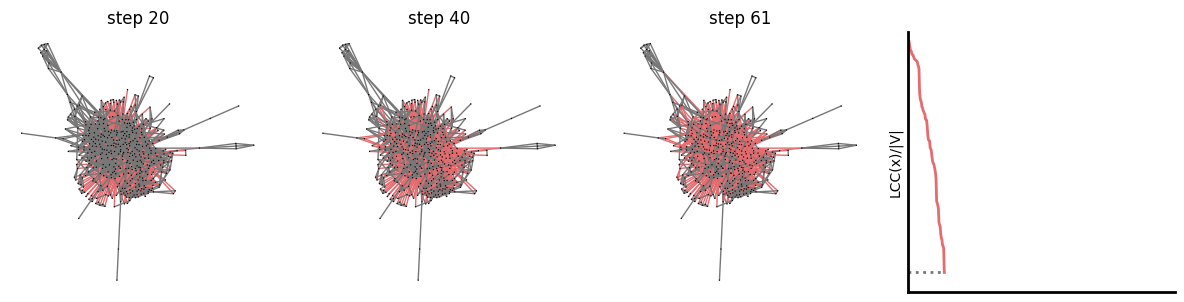

Loaded graph bio_maayan-figeys
bio_arenas-meta: AUC=37.72810890360559
bio_foodweb-baydry, AUC=45.05


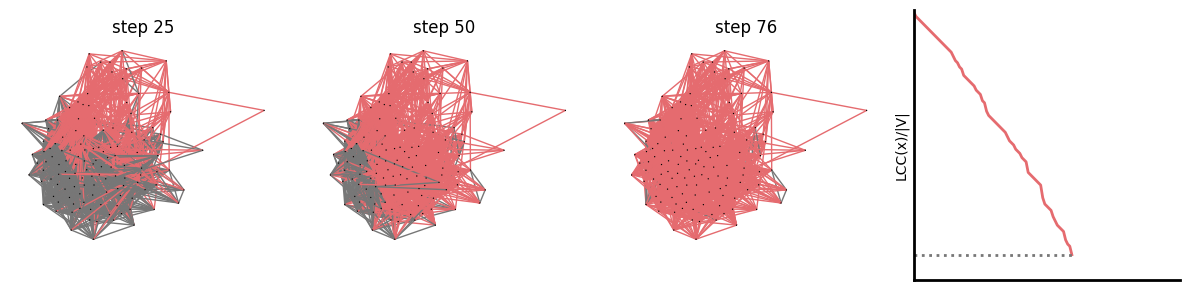

Loaded graph bio_maayan-foodweb
bio_foodweb-baydry: AUC=45.0546875
bio_foodweb-baywet, AUC=45.07


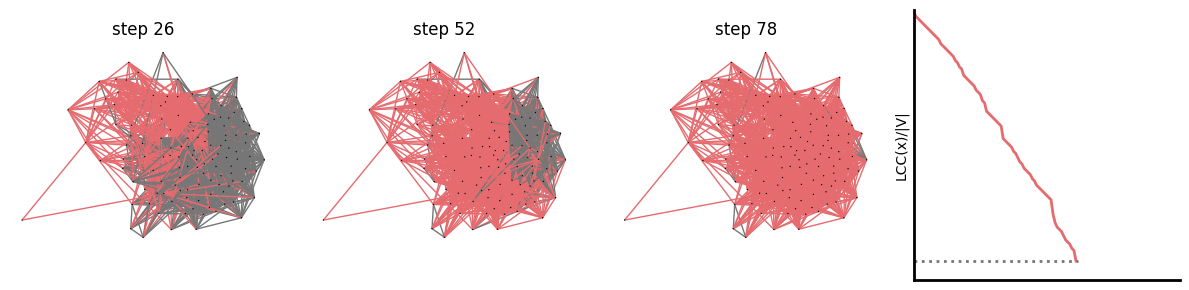

Loaded graph bio_maayan-vidal
bio_foodweb-baywet: AUC=45.06770833333333
bio_maayan-Stelzl, AUC=61.42


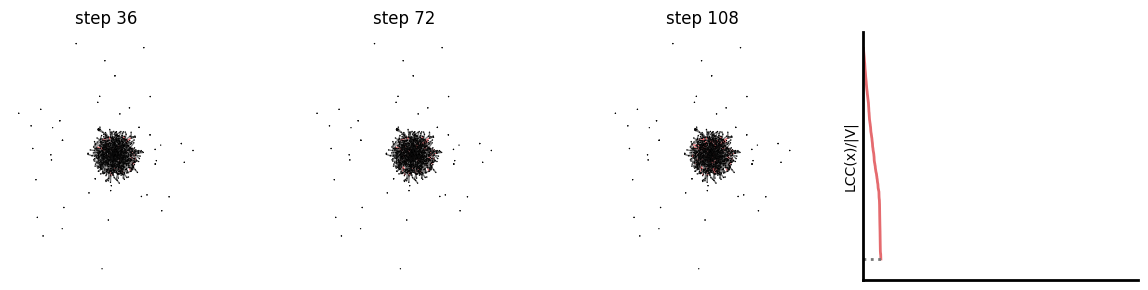

Loaded graph bio_moreno_propro
bio_maayan-Stelzl: AUC=61.42399374755764
bio_dimacs10-celegansneural, AUC=70.43


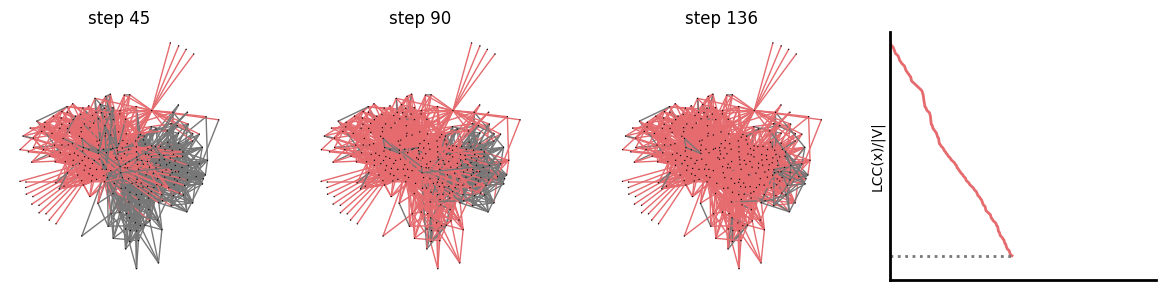

bio_dimacs10-celegansneural: AUC=70.43434343434342
bio_maayan-foodweb, AUC=31.97


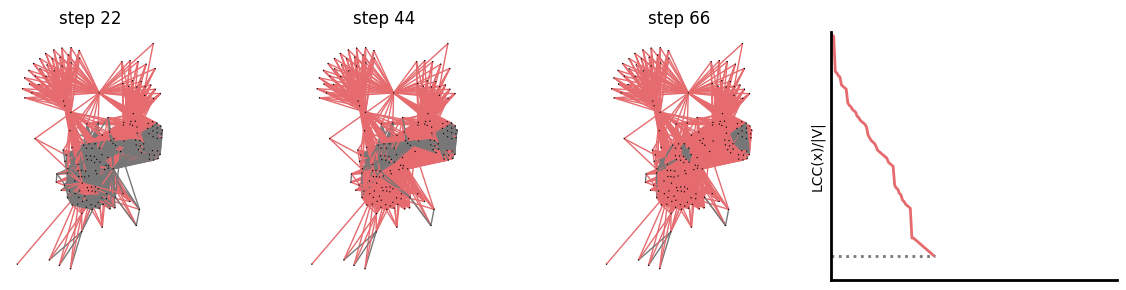

bio_maayan-foodweb: AUC=31.974499089253186
bio_moreno_propro, AUC=38.07


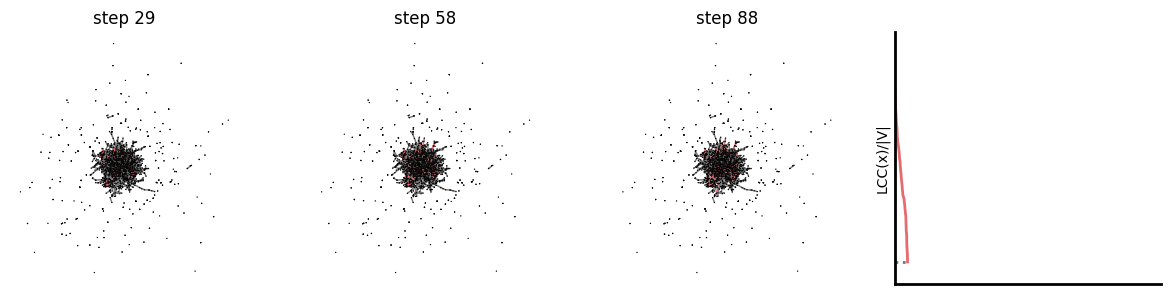

bio_moreno_propro: AUC=38.06559714795009
bio_maayan-figeys, AUC=63.69


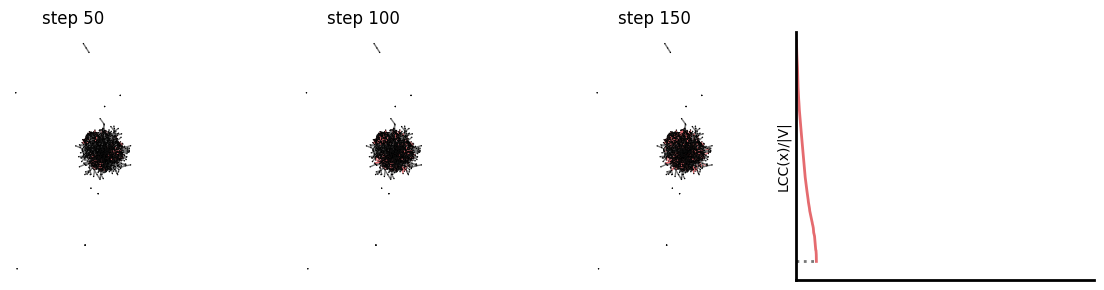

bio_maayan-figeys: AUC=63.69435760011909
bio_maayan-vidal, AUC=160.96


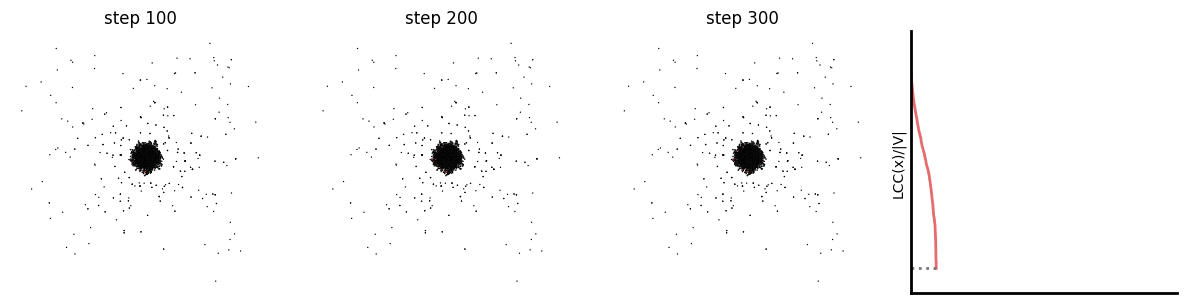

bio_maayan-vidal: AUC=160.95797425258007


In [1]:
from env import DismantleEnv
from utils import validate
import torch

from networks.dismantle import SACPolicy

render = True

# env = DismantleEnv('graphs/example', batch_size=5, is_val=True, render='plot')
env = DismantleEnv('graphs/real/bio', batch_size=5, is_val=True, render='plot')

sac = SACPolicy(
    num_features=16,
    num_heads=4,
    num_mps=6,
).to(torch.device('cpu'))
sac.load_state_dict(torch.load('saved/mind.ckpt', weights_only=True)['policy_state_dict'])

auc_list = validate(env, sac)